In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spectral.io import envi
from spectral.io.envi import read_envi_header, write_envi_header
from glob import glob
import rasterio
from rasterio.windows import from_bounds, Window

from utilities import *

In [2]:
# identiy three test rois - one around the calibration tarps, two in the main flight area: dense aspen, dense conifer
# just using orthorectified data for now because SOME of the reprocessed rdn data tristan gave us is only ort, no raw

# for cal tarps, get subsets for each relevant flightline

In [5]:
home = '/store/carroll/col/2018/'
cal = home+'raw/calibration_flights/' # calibration flights from Tristan
rmbl = '/store/carroll/col/2018/raw/rmbl/' # reprocessed data from Tristan
out = home+'test_roi/'
os.makedirs(out, exist_ok=True)

buf = 25

In [3]:
# # # add byte order to all new data associated w this flightline
# # fps = glob(rmbl + f'*/*{flight}*.hdr')
# fps = glob(cal + f'*/*.hdr')

# for fp in fps:
#     add_byte_order(fp)


 NIS01_20180611_172310


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.045466654..1.5].


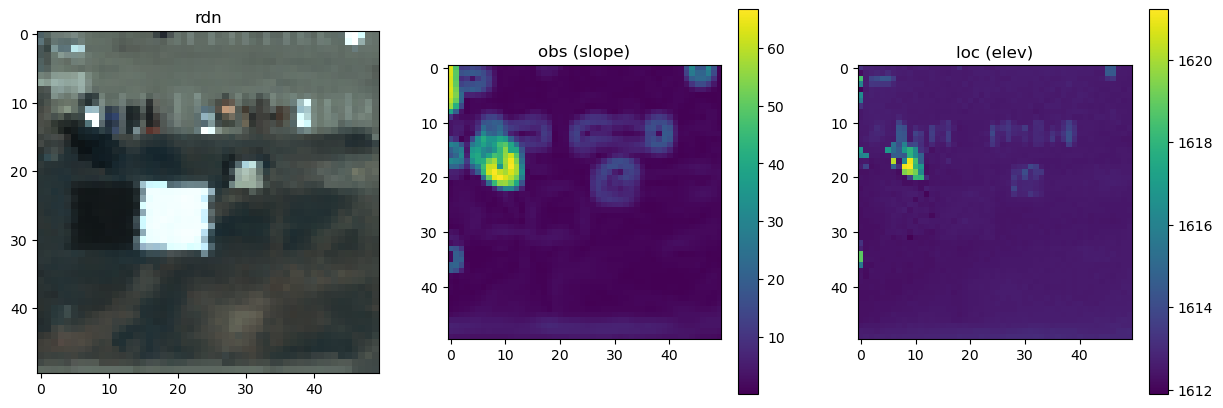


 NIS01_20180611_172711


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.045791857..1.5].


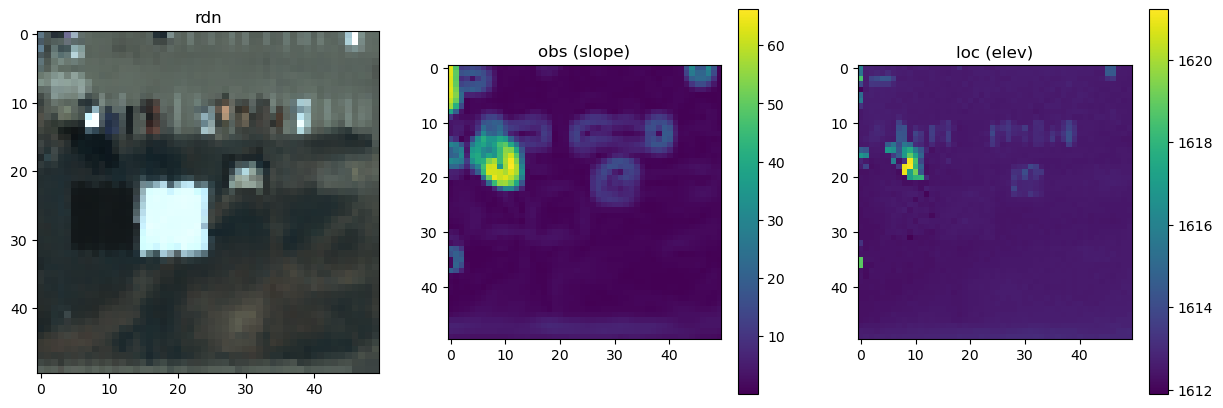


 NIS01_20180611_173116


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.04809466..1.5].


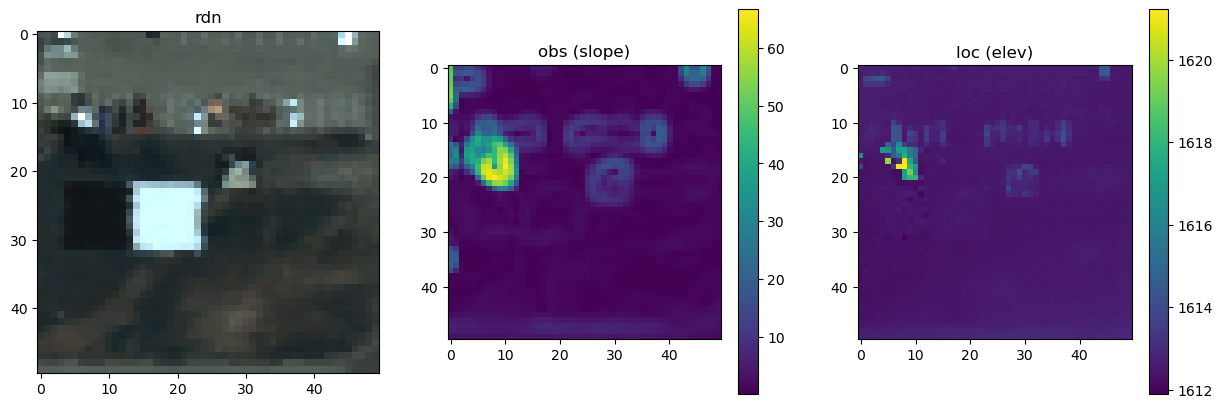


 NIS01_20180611_173537


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.043238934..1.5].


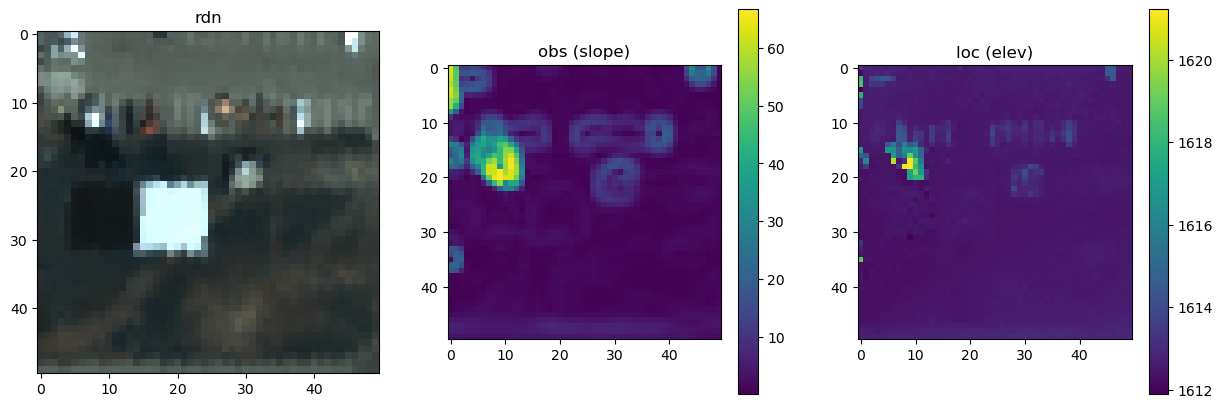

In [11]:
# cal tarp

# Tristan email: Calibration tarps are located at 480273E, 4431900N
x, y = 480273, 4431900

output_dir = out+'calTarp/subset/'
os.makedirs(output_dir, exist_ok=True)

cal_flightlines = [x.split('/')[-1].strip('_rdn') for x in glob(cal + f'*/*_rdn')]

for flight in cal_flightlines:
    print('\n', flight)
    subset_region_ort(
        fp_rdn = cal+f'L1/{flight}_rdn_ort.hdr',
        fp_obs = cal+f'L1/{flight}_rdn_obs_ort.hdr',
        fp_igm = cal+f'L1/{flight}_rdn_ort_igm_ort.hdr',
        output_dir = output_dir,
        x = x,
        y = y,
        buf = buf,
        brighten_factor=1.5
    )

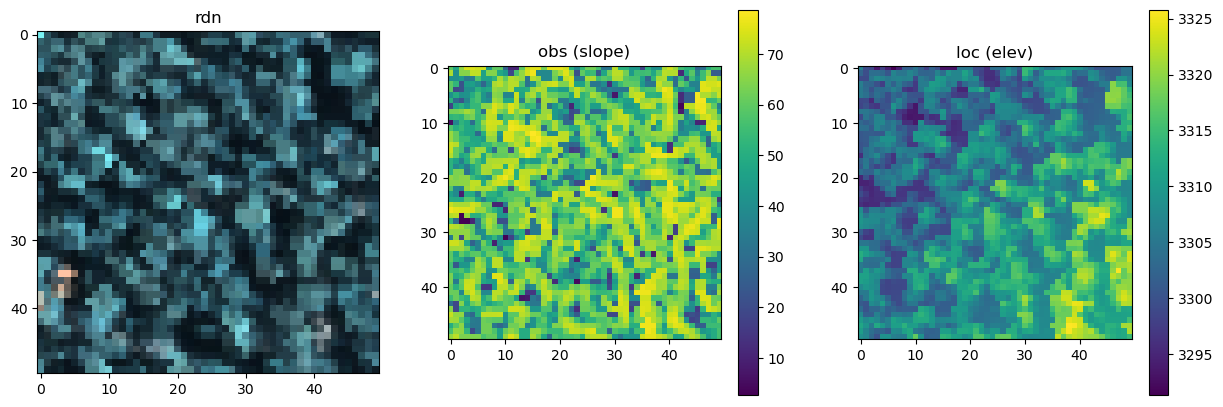

In [6]:
# main flight area - conifer

# visually selected a point in the middle of a dense conifer stand
x, y = 327125.78,4311428.84

flight = 'NIS01_20180619_160339' # previously identified

output_dir = out+'conifer/subset/'
os.makedirs(output_dir, exist_ok=True)

subset_region_ort(
    fp_rdn = glob(rmbl+f'*/{flight}_rdn_ort.hdr')[0],
    fp_obs = glob(rmbl+f'*/{flight}_rdn_obs_ort.hdr')[0],
    fp_igm = glob(rmbl+f'*/{flight}_rdn_ort_igm_ort.hdr')[0],
    output_dir = output_dir,
    x = x,
    y = y,
    buf = buf
)

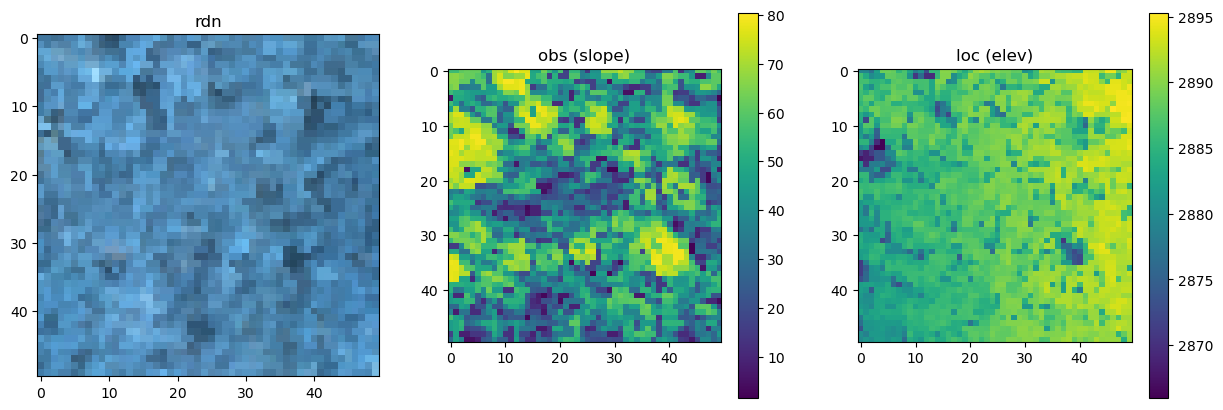

In [5]:
# main flight area - aspen

# visually selected a point in the middle of a dense aspen stand
x, y = 324787.29, 4308930.18

# # select a flight id
flight = 'NIS01_20180619_172934' # previously identified

output_dir = out+'aspen/subset/'
os.makedirs(output_dir, exist_ok=True)

subset_region_ort(
    fp_rdn = glob(rmbl+f'*/{flight}_rdn_ort.hdr')[0],
    fp_obs = glob(rmbl+f'*/{flight}_rdn_obs_ort.hdr')[0],
    fp_igm = glob(rmbl+f'*/{flight}_rdn_ort_igm_ort.hdr')[0],
    output_dir = output_dir,
    x = x,
    y = y,
    buf = buf
)

# why is this so blue?

In [26]:
fp_igm = '/store/brodrick/col/mosaics/built_mosaic/min_phase_igm.hdr'

igm = envi.open(fp_igm).open_memmap(interleave='bip').copy()
rows, cols = igm[...,0].shape
flat_x = igm[...,0].flatten()
flat_y = igm[...,1].flatten()
diffs = np.abs(flat_x - x) + np.abs(flat_y - y)
idx = np.argmin(diffs)
row, col = np.unravel_index(idx, (rows, cols))
print(row, col)

# rfl
fp = '/store/brodrick/col/mosaics/built_mosaic/min_phase_refl.hdr'
fp_out = out+'/aspen/subset/min_phase_refl.hdr'
meta = envi.open(fp).metadata
meta['lines'] = buf*2
meta['samples'] = buf*2
out_ds = envi.create_image(fp_out, meta, ext='', force=True)
out_ds.open_memmap(writable=True)[:,:,:] = envi.open(fp).open_memmap(interleave='bip')[row-buf:row+buf, col-buf:col+buf, :].copy()
rgb = envi.open(fp_out).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
del out_ds

# rfl isofit
fp = '/store/brodrick/col/mosaics/built_mosaic/min_phase_isofit_rfl.hdr'
fp_out = out+'/aspen/subset/min_phase_isofit_rfl.hdr'
meta = envi.open(fp).metadata
meta['lines'] = buf*2
meta['samples'] = buf*2
out_ds = envi.create_image(fp_out, meta, ext='', force=True)
out_ds.open_memmap(writable=True)[:,:,:] = envi.open(fp).open_memmap(interleave='bip')[row-buf:row+buf, col-buf:col+buf, :].copy()
rgb = envi.open(fp_out).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
del out_ds

15238 8935


(50, 50, 3) (50, 50, 3)


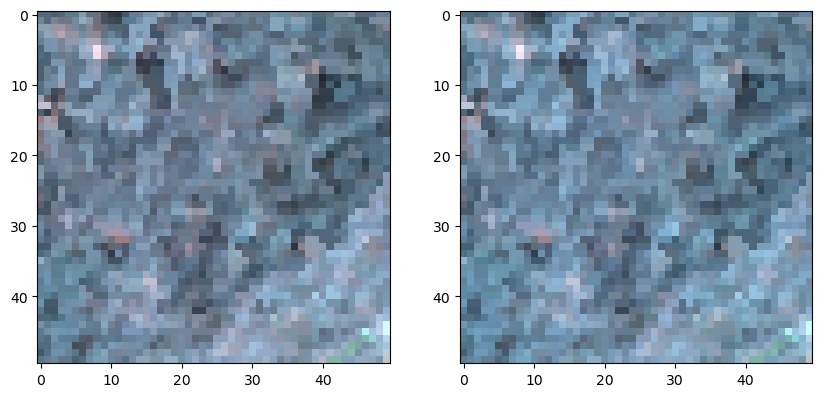

In [27]:
rgb = np.moveaxis(rasterio.open(out+'/aspen/subset/min_phase_refl').read([60,40,30]), 0, 2)
rgb_isofit = np.moveaxis(rasterio.open(out+'/aspen/subset/min_phase_isofit_rfl').read([60,40,30]), 0, 2)

print(rgb.shape, rgb_isofit.shape)

fig, axs = plt.subplots(ncols=2, figsize=(10,5))
axs[0].imshow(rgb / np.max(rgb, axis=(0, 1)))
axs[1].imshow(rgb_isofit / np.max(rgb_isofit, axis=(0, 1)))
plt.show()